# Calculating the design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random
import os
from scipy.stats import skewnorm
from nilearn.glm.first_level import compute_regressor
from nilearn.glm.first_level import spm_hrf
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix
import utils

plt.rcParams.update(plt.rcParamsDefault)
pd.set_option('display.max_rows', None)

In [50]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','planning')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [51]:
input_dir = '/Volumes/project/3025011.02/raw/sub-x003/ses-01/beh/'
subject_id = 'x003'
session_number = '01'
data = pd.read_csv(os.path.join(input_dir, 'behavioural_output_sub-601_session-01_skyra_2024-11-20_16-44-44.csv'), sep= ';')
data = data.sort_values(by=['trial'], ascending=[True])
data = data.reset_index(drop=True)
print(data)

     trial  emotional_cue_time response objectively_correct  \
0        0          1732117568       up                Even   
1        1          1732117572     down                Even   
2        2          1732117576     down                Even   
3        3          1732117579       up                Even   
4        4          1732117583       up                Even   
5        5          1732117587       up                Even   
6        6          1732117590     down                Even   
7        7          1732117593       up                Even   
8        8          1732117597     down                True   
9        9          1732117601       up                True   
10      10          1732117604     down                True   
11      11          1732117607       up                True   
12      12          1732117611       up                True   
13      13          1732117615       up               False   
14      14          1732117619     down                

# Do we need to do anything with CPU time?

In [52]:
data['congruency'] = data.apply(utils.analysis_functions.check_congruency, axis=1)
data['valence'] = data.apply(utils.analysis_functions.check_valence, axis=1)
data['subject_id'] = subject_id
data['session'] = session_number
data = utils.analysis_functions.check_volatility(data)

print(data)

     trial  emotional_cue_time response objectively_correct  \
0        0          1732117568       up                Even   
1        1          1732117572     down                Even   
2        2          1732117576     down                Even   
3        3          1732117579       up                Even   
4        4          1732117583       up                Even   
5        5          1732117587       up                Even   
6        6          1732117590     down                Even   
7        7          1732117593       up                Even   
8        8          1732117597     down                True   
9        9          1732117601       up                True   
10      10          1732117604     down                True   
11      11          1732117607       up                True   
12      12          1732117611       up                True   
13      13          1732117615       up               False   
14      14          1732117619     down                

# Quickly recode into something the design matrix can use

In [53]:
data['valence'] = data['valence'].replace({0:'angry', 1:'happy'})
data['congruency'] = data['congruency'].replace({0:'incongruent', 1:'congruent'})
data['volatility'] = data['volatility'].replace({0:'stable', 1:'volatile'})
data['valence-volatility'] = data['valence'] + '-' + data['volatility']

data['onset'] = data['emotional_cue_time']
data['duration'] = 1.7
print(data[['valence','congruency','volatility','valence-volatility','duration']])

    valence   congruency volatility valence-volatility  duration
0     happy    undefined   volatile     happy-volatile       1.7
1     angry    undefined     stable       angry-stable       1.7
2     happy    undefined   volatile     happy-volatile       1.7
3     happy    undefined   volatile     happy-volatile       1.7
4     angry    undefined     stable       angry-stable       1.7
5     angry    undefined     stable       angry-stable       1.7
6     angry    undefined     stable       angry-stable       1.7
7     happy    undefined   volatile     happy-volatile       1.7
8     angry  incongruent   volatile     angry-volatile       1.7
9     happy  incongruent   volatile     happy-volatile       1.7
10    angry  incongruent   volatile     angry-volatile       1.7
11    happy  incongruent   volatile     happy-volatile       1.7
12    happy  incongruent   volatile     happy-volatile       1.7
13    angry  incongruent   volatile     angry-volatile       1.7
14    angry  incongruent 

# Restructure the data into a timeseries

In [54]:
# Create the new dataframe by transforming the data
restructured_rows = []
for _, row in data.iterrows():
    restructured_rows.append({'trial_type': row['congruency'], 'onset': row['onset'], 'duration': row['duration']})
    restructured_rows.append({'trial_type': row['valence-volatility'], 'onset': row['onset'], 'duration': row['duration']})

# Convert to dataframe
data_design_matrix = pd.DataFrame(restructured_rows)

print(data_design_matrix)

          trial_type       onset  duration
0          undefined  1732117568       1.7
1     happy-volatile  1732117568       1.7
2          undefined  1732117572       1.7
3       angry-stable  1732117572       1.7
4          undefined  1732117576       1.7
5     happy-volatile  1732117576       1.7
6          undefined  1732117579       1.7
7     happy-volatile  1732117579       1.7
8          undefined  1732117583       1.7
9       angry-stable  1732117583       1.7
10         undefined  1732117587       1.7
11      angry-stable  1732117587       1.7
12         undefined  1732117590       1.7
13      angry-stable  1732117590       1.7
14         undefined  1732117593       1.7
15    happy-volatile  1732117593       1.7
16       incongruent  1732117597       1.7
17    angry-volatile  1732117597       1.7
18       incongruent  1732117601       1.7
19    happy-volatile  1732117601       1.7
20       incongruent  1732117604       1.7
21    angry-volatile  1732117604       1.7
22       in

# Export to tsv

In [ ]:
something

# Scanner info

In [55]:
# Repetition time
tr = 1.5

# Define scan volumes
time_length = math.ceil(max(data_design_matrix['onset']))
n_volumes = np.arange(0, time_length, tr)
total_volumes = len(n_volumes)
print(n_volumes)

[0.00000000e+00 1.50000000e+00 3.00000000e+00 ... 1.73212014e+09
 1.73212014e+09 1.73212014e+09]


# Design matrix

In [56]:
plot_name = 'Design matrix'
events = pd.DataFrame(
    {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
)
print(events)

          trial_type       onset  duration
0          undefined  1732117568       1.7
1     happy-volatile  1732117568       1.7
2          undefined  1732117572       1.7
3       angry-stable  1732117572       1.7
4          undefined  1732117576       1.7
5     happy-volatile  1732117576       1.7
6          undefined  1732117579       1.7
7     happy-volatile  1732117579       1.7
8          undefined  1732117583       1.7
9       angry-stable  1732117583       1.7
10         undefined  1732117587       1.7
11      angry-stable  1732117587       1.7
12         undefined  1732117590       1.7
13      angry-stable  1732117590       1.7
14         undefined  1732117593       1.7
15    happy-volatile  1732117593       1.7
16       incongruent  1732117597       1.7
17    angry-volatile  1732117597       1.7
18       incongruent  1732117601       1.7
19    happy-volatile  1732117601       1.7
20       incongruent  1732117604       1.7
21    angry-volatile  1732117604       1.7
22       in

# Export as TSV

In [57]:
output_dir.mkdir(exist_ok=True, parents=True)
tsvfile = output_dir / "localizer_events.tsv"
events.to_csv(tsvfile, sep="\t", index=False)
print(f"The event information has been saved to {tsvfile}")

AttributeError: 'str' object has no attribute 'mkdir'

In [290]:
design_matrix = make_first_level_design_matrix(
    n_volumes,
    data_design_matrix,
    drift_model = None
)
design_matrix = design_matrix[['angry-stable','happy-stable','angry-volatile','happy-volatile','congruent','incongruent','constant']]
print(design_matrix)

        angry-stable  happy-stable  angry-volatile  happy-volatile     congruent   incongruent  constant
0.0    -5.900697e-15 -6.154487e-15   -4.566033e-15   -6.646980e-15  4.296545e-15  5.866532e-15       1.0
1.5    -2.371467e-15  4.070965e-03   -1.672764e-15   -2.519938e-15  5.300091e-17  4.070965e-03       1.0
3.0     2.682946e-15  1.060220e-01    2.373831e-15    2.686705e-15 -4.362340e-15  1.060220e-01       1.0
4.5    -1.064594e-14  3.605636e-01   -8.701983e-15   -1.345369e-14  9.683356e-15  3.605636e-01       1.0
6.0     6.581781e-15  4.928976e-01    5.266393e-15    7.208191e-15 -7.075906e-15  4.928976e-01       1.0
7.5    -2.901371e-16  5.082049e-01   -3.150716e-16   -5.769048e-16 -2.434383e-16  5.082049e-01       1.0
9.0     5.478077e-13  5.673585e-01    1.691388e-17   -8.213843e-17 -4.578260e-16  5.673585e-01       1.0
10.5    5.011041e-03  5.063076e-01   -2.383006e-16   -4.272186e-16 -3.364475e-16  5.113187e-01       1.0
12.0    1.143981e-01  2.979781e-01   -1.384551e-16   -2

/Users/kenneth.van.der.zee/Documents/phd_1_analysis/venv/lib/python3.10/site-packages/nilearn/glm/_utils.py:180: UserWarning: Matrix is singular at working precision, regularizing...
  warn("Matrix is singular at working precision, regularizing...")


<Figure size 1500x400 with 0 Axes>

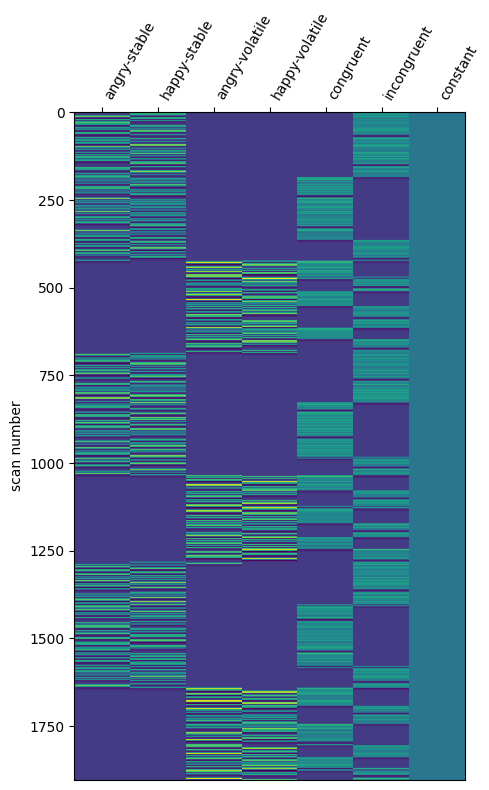

In [291]:
fig, ax = plt.subplots(figsize=(5, 8), nrows=1, ncols=1)
plot_design_matrix(design_matrix, ax=ax)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

## Correlation matrix of the regressors

In [292]:
pd.set_option('display.width', 200)
correlation_matrix = design_matrix.corr()
correlation_matrix.round(3).to_csv(os.path.join(output_dir, 'regression_correlation_matrix.csv'), sep=';')
print(correlation_matrix)

                angry-stable  happy-stable  angry-volatile  happy-volatile  congruent  incongruent  constant
angry-stable        1.000000     -0.337529       -0.282201       -0.284800   0.018453     0.127808  0.299629
happy-stable       -0.337529      1.000000       -0.273265       -0.283408   0.030646     0.130229  0.134627
angry-volatile     -0.282201     -0.273265        1.000000       -0.200315   0.132295     0.000767 -0.334887
happy-volatile     -0.284800     -0.283408       -0.200315        1.000000   0.074880     0.014618 -0.320394
congruent           0.018453      0.030646        0.132295        0.074880   1.000000    -0.783496 -0.287428
incongruent         0.127808      0.130229        0.000767        0.014618  -0.783496     1.000000  0.169096
constant            0.299629      0.134627       -0.334887       -0.320394  -0.287428     0.169096  1.000000


# Raw HRF

In [293]:
plot_name = f'HRF for valence, first 200s, median ITI {median_iti}'
first_volume = 660
length = 860

fig = plt.figure(figsize=(15, 4))

n_volumes_selection = n_volumes[first_volume:length+1]
design_matrix_hrf_plot = design_matrix[first_volume:length]
#design_matrix_hrf_plot = design_matrix_hrf_plot.drop(columns=['congruent', 'incongruent', 'angry-stable', 'happy-stable', 'constant'])

plt.plot(design_matrix_hrf_plot['volatile'], label='angry-volatile', color='r')
plt.plot(design_matrix_hrf_plot['stable'], label='happy-volatile', color='g')
plt.xlabel("time (s)")
plt.legend()
plt.title(plot_name)

# adjust plot
plt.subplots_adjust(bottom=0.12)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_4649/1615567232.py:8: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  design_matrix_hrf_plot = design_matrix[first_volume:length]


KeyError: 'volatile'